In [16]:
import pathlib
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

In [17]:
train_folder = pathlib.Path("..") / "assets" / "simulated_dataset" / "train"

train_dataframes = {
    csv_file.stem: pd.read_csv(csv_file)
    for csv_file in train_folder.glob("*.csv")
}

list(train_dataframes.keys())

['tbm_failure_logs_combined_train',
 'tbm_ts_truck_brake_train',
 'tbm_ts_truck_tire_train',
 'tbm_ts_van_brake_train',
 'tbm_ts_van_tire_train']

In [18]:
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)
for name, df in train_dataframes.items():
	print(f"{name}:")
	print(df.head())
	print("-" * 120)

tbm_failure_logs_combined_train:
   machine_id  failure_time  region  route       speed      load failure_type car_type  route_ratio
0           1          37.0     2.0    0.0  103.462715  0.633820        Tires   Trucks    10.904762
1           1          46.0     2.0    0.0   98.352409  0.555570        Tires   Trucks    10.904762
2           1          67.0     2.0    0.0  102.767014  0.519141        Tires   Trucks    10.904762
3           1          94.0     2.0    0.0  102.561248  0.642696        Tires   Trucks    10.904762
4           1          98.0     2.0    0.0  109.632201  0.636569       Brakes   Trucks    10.904762
------------------------------------------------------------------------------------------------------------------------
tbm_ts_truck_brake_train:
   machine_id  time car_type  region  route  route_ratio       speed      load  failure_occurred failure_type
0           1   0.0   Trucks       2      0    10.904762  106.526257  0.494003                 0          NaN


In [19]:
for df_name, df in train_dataframes.items():
    print(f"{df_name}: {len(df)} rows")

tbm_failure_logs_combined_train: 13072 rows
tbm_ts_truck_brake_train: 170000 rows
tbm_ts_truck_tire_train: 170000 rows
tbm_ts_van_brake_train: 170000 rows
tbm_ts_van_tire_train: 170000 rows


In [20]:
truck_brake_df = train_dataframes['tbm_ts_truck_brake_train'].copy()

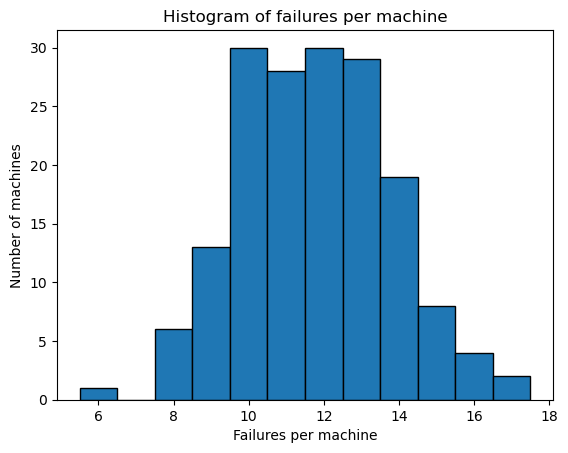

In [21]:
failures_per_machine = (
    truck_brake_df.groupby("machine_id")["failure_occurred"]
    .sum()
    .astype(int)
    .rename("failure_count")
)

ax = failures_per_machine.plot.hist(
    bins=np.arange(failures_per_machine.min() - 0.5, failures_per_machine.max() + 1.5, 1),
    edgecolor="black"
)
ax.set_xlabel("Failures per machine")
ax.set_ylabel("Number of machines")
ax.set_title("Histogram of failures per machine")
plt.show()

In [22]:
# transform dataframe from time-based to event-based (one row per failure)

failure_rows = []

tb_sorted = truck_brake_df.sort_values(["machine_id", "time"])

for machine_id, g in tb_sorted.groupby("machine_id", sort=False):
    g = g.reset_index(drop=True)
    failure_pos = np.flatnonzero(g["failure_occurred"].to_numpy() == 1)

    for k, pos in enumerate(failure_pos):
        prev_pos = None if k == 0 else failure_pos[k - 1]
        start = 0 if prev_pos is None else prev_pos + 1
        seg = g.iloc[start : pos + 1]

        route_frac = seg["route"].value_counts(normalize=True)
        t_curr = g.at[pos, "time"]
        t_prev = g.at[prev_pos, "time"] if prev_pos is not None else 0.0

        failure_rows.append(
            {
                "machine_id": machine_id,
                "failure_time": float(t_curr - t_prev),
                "route_frac_HW": float(route_frac.get(0, 0.0)),
                "route_frac_city": float(route_frac.get(1, 0.0)),
                "region": g.at[pos, "region"],
                "avg_speed": float(seg["speed"].mean()),
                "avg_load": float(seg["load"].mean()),
            }
        )

failure_summary_df = pd.DataFrame(failure_rows)
failure_summary_df.head()

,machine_id,failure_time,route_frac_HW,route_frac_city,region,avg_speed,avg_load
0,1,98.0,0.929293,0.070707,2,95.851951,0.609040
1,1,22.0,0.818182,0.181818,2,87.433444,0.627943
2,1,55.0,0.927273,0.072727,2,95.663184,0.603490
3,1,71.0,0.845070,0.154930,2,88.529533,0.608592
4,1,134.0,0.925373,0.074627,2,93.781851,0.604270


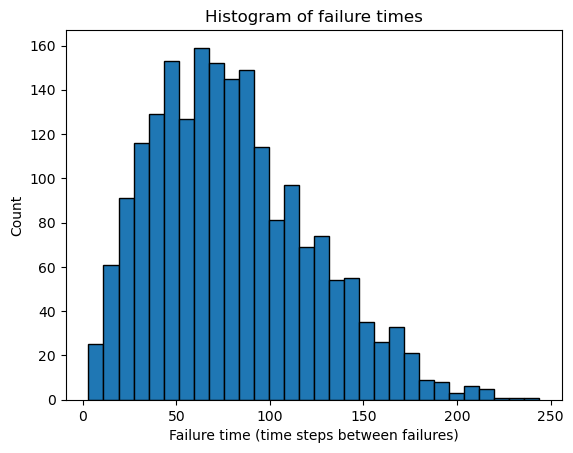

In [23]:
ax = failure_summary_df["failure_time"].plot.hist(bins=30, edgecolor="black")
ax.set_xlabel("Failure time (time steps between failures)")
ax.set_ylabel("Count")
ax.set_title("Histogram of failure times")
plt.show()

In [24]:
machine_idx, machine_levels = pd.factorize(failure_summary_df["machine_id"])
first_machine_idx = pd.Series(machine_idx).drop_duplicates().index.to_numpy()

regions = failure_summary_df['region'][first_machine_idx].to_numpy()
region_idx, region_levels = pd.factorize(failure_summary_df['region'])

In [25]:
coords = {
	"failures": np.arange(len(failure_summary_df)),
	"machine": machine_levels,
	"region": region_levels,
	"route type": np.array([0, 1]),
}

with pm.Model(coords=coords) as truck_brake_model:
	# input data
	fHW = pm.Data("HW fraction", failure_summary_df["route_frac_HW"], dims="failures")
	fCity = pm.Data("City fraction", failure_summary_df["route_frac_city"], dims="failures")
	reg = pm.Data("Region", regions, dims="machine")
	speed = pm.Data("Speed", failure_summary_df["avg_speed"], dims="failures")
	load = pm.Data("Load", failure_summary_df["avg_load"], dims="failures")

	# parameter priors
	# the beta of the Weibull (see below) corresponds to the scale or average failure time, hence the priors of roeff
	# the priors of the other effects are set such that their expected contribution to the failure time is around 1 (or zero in the potential), 
	# i.e. no effect, the sigma is set completely arbitrarily, but it turns out to converge well to much higher values
	roeff = pm.HalfNormal("route effect", sigma=failure_summary_df["failure_time"].mean(), dims="route type")
	regeff = pm.Normal("region effect", mu=0.0, sigma=1.0, dims="region")
	speedeff = pm.Normal("speed effect", mu=0.0, sigma=1.0/failure_summary_df["avg_speed"].mean())
	loadeff = pm.Normal("load effect", mu=0.0, sigma=1.0/failure_summary_df["avg_load"].mean())

	# covariates effect
	le = pm.Deterministic("longterm effect", roeff[0]*fHW + roeff[1]*fCity, dims="failures")
	ie = pm.Deterministic("immediate effect", regeff[reg[machine_idx]] + speedeff*speed + loadeff*load, dims="failures")

	# likelihood
	failure_time = pm.Weibull("failure time", alpha=2.0, beta=le, observed=failure_summary_df["failure_time"], dims="failures")
	pm.Potential("immediate effect correction", pm.math.sum(ie))
	# pm.Potential("immediate effect correction", ie, dims="failures")
	# note: the latter command would be preferred but currently pymc fucks up the graphviz plot (try and see for yourself)


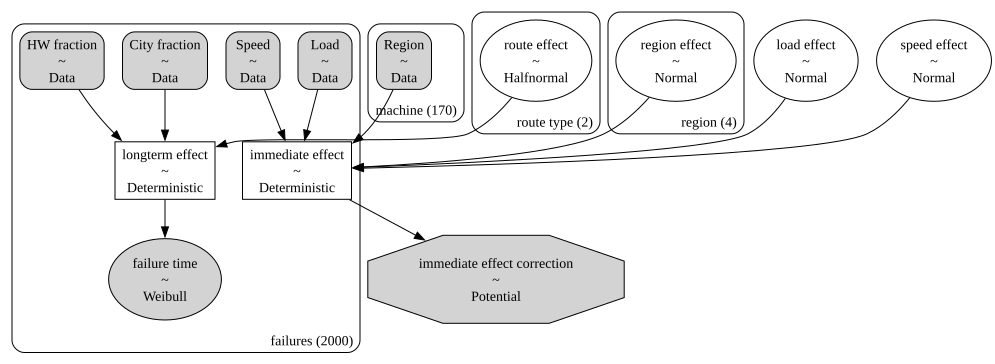

In [26]:
pm.model_to_graphviz(model=truck_brake_model)

In [27]:
trace = pm.sample(model=truck_brake_model, target_accept=0.95) # increased target_accept to reduce/avoid divergences

c:\Users\erik.hostens\AppData\Local\miniforge3\envs\Flambay\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [route effect, region effect, speed effect, load effect]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 65 seconds.


In [28]:
# sampling in vanilla pymc is sufficiently fast, no need for nutpie for now
# import nutpie
# compiled = nutpie.compile_pymc_model(model=truck_brake_model, backend="jax", gradient_backend="jax")
# trace = nutpie.sample(compiled)

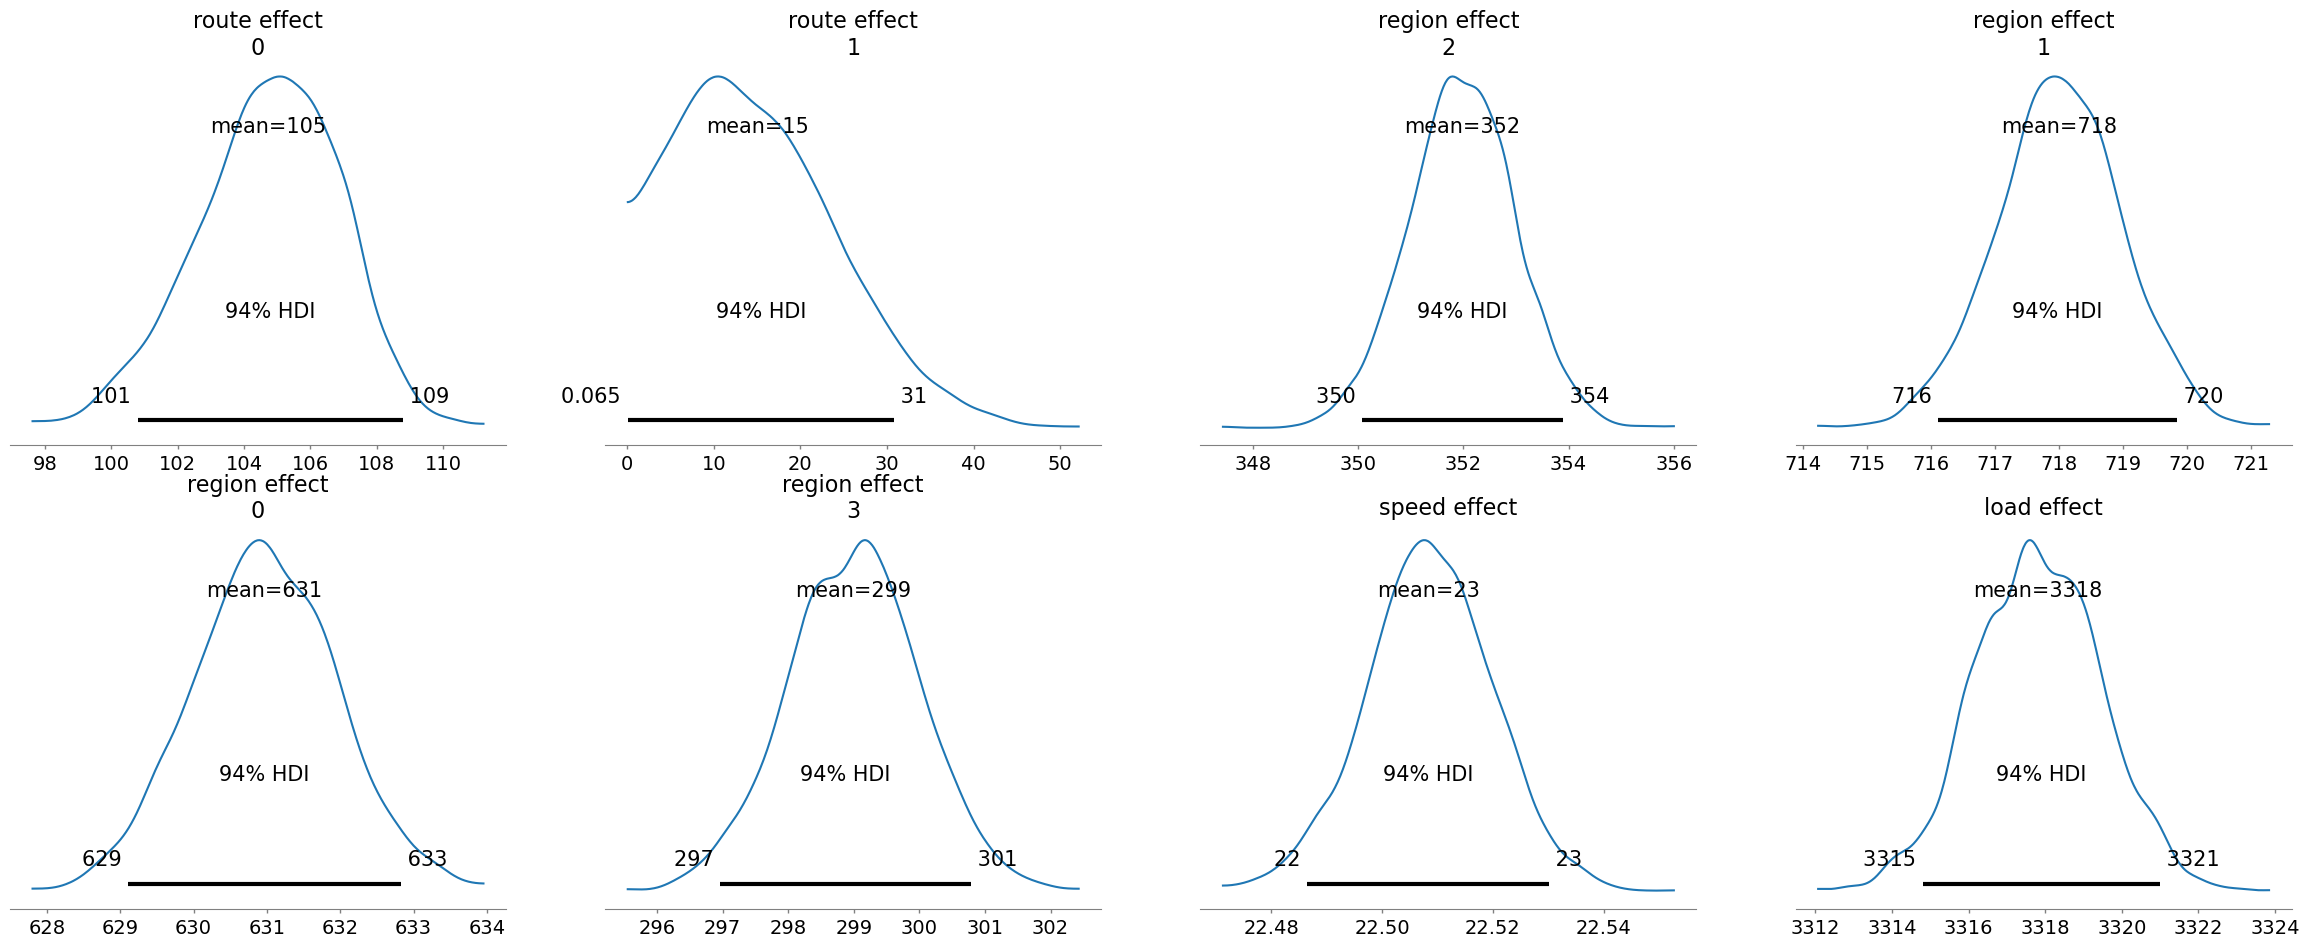

In [29]:
_ = pm.plot_posterior(trace, var_names=["route effect", "region effect", "speed effect", "load effect"])